In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


In [2]:
dataset = pd.read_csv('/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv')
dataset = dataset.sample(n=10000, random_state=42)

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 3737323 to 1615363
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            10000 non-null  int64  
 1   type            10000 non-null  object 
 2   amount          10000 non-null  float64
 3   nameOrig        10000 non-null  object 
 4   oldbalanceOrg   10000 non-null  float64
 5   newbalanceOrig  10000 non-null  float64
 6   nameDest        10000 non-null  object 
 7   oldbalanceDest  10000 non-null  float64
 8   newbalanceDest  10000 non-null  float64
 9   isFraud         10000 non-null  int64  
 10  isFlaggedFraud  10000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 937.5+ KB


In [4]:
# Data Cleaning
# Change from int64 to bool columns ['isFraud'] and [isFlaggedFraud]
dataset['isFraud'] = dataset['isFraud'].astype('bool')
dataset['isFlaggedFraud'] = dataset['isFlaggedFraud'].astype('bool')

In [5]:
# Quality check
print('Nulls per column:\n', dataset.isnull().sum())
print('Duplicates per column:\n', dataset.duplicated().sum())
dataset

Nulls per column:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
Duplicates per column:
 0


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3737323,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,False,False
264914,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,False,False
85647,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,False,False
5899326,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,False,False
2544263,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,False,False
...,...,...,...,...,...,...,...,...,...,...,...
4094229,301,CASH_OUT,80646.44,C819258095,8298.00,0.00,C1433007346,222649.51,303295.96,False,False
5603252,394,CASH_IN,57501.43,C1316678628,1355549.25,1413050.68,C483888900,342052.10,284550.67,False,False
6189570,570,CASH_OUT,112497.83,C765932428,31327.00,0.00,C355959262,314691.28,427189.10,False,False
5853779,402,PAYMENT,557.43,C2108927530,288151.00,287593.57,M918034835,0.00,0.00,False,False


In [6]:
# Exploratory Data Analysis (EDA)
## Transactions Distribution: Normal and Fraud
total_trans = len(dataset)
fraud = dataset['isFraud'].sum()
frauds_total_amount = dataset[dataset['isFraud']==1]['amount'].sum()

print('1. TRANSACTIONS DISTRIBUTION')
print(f"Analyzed Transactions {total_trans}\n")
print(f"Fraudulent Transactions: {fraud}\n")
print(f"Average Fruaudlent Transactions: {dataset['isFraud'].mean()*100:.2f} %\n")


1. TRANSACTIONS DISTRIBUTION
Analyzed Transactions 10000

Fraudulent Transactions: 19

Average Fruaudlent Transactions: 0.19 %



In [7]:

## In what type of transaction is fraud focused? 
fraud_per_type = dataset.groupby('type')['isFraud'].agg([
    'count', 'sum', 'mean'
])
fraud_per_type.columns = ['totalTransactions', 'fraudulentTransactions', 'fraudRate']
fraud_per_type['fraudRate']*=100
print('\n2. FRAUD PER TRANSACTION TYPE')
print(fraud_per_type.sort_values(by='fraudulentTransactions', ascending=False))


2. FRAUD PER TRANSACTION TYPE
          totalTransactions  fraudulentTransactions  fraudRate
type                                                          
CASH_OUT               3500                      12   0.342857
TRANSFER                835                       7   0.838323
CASH_IN                2224                       0   0.000000
DEBIT                    58                       0   0.000000
PAYMENT                3383                       0   0.000000


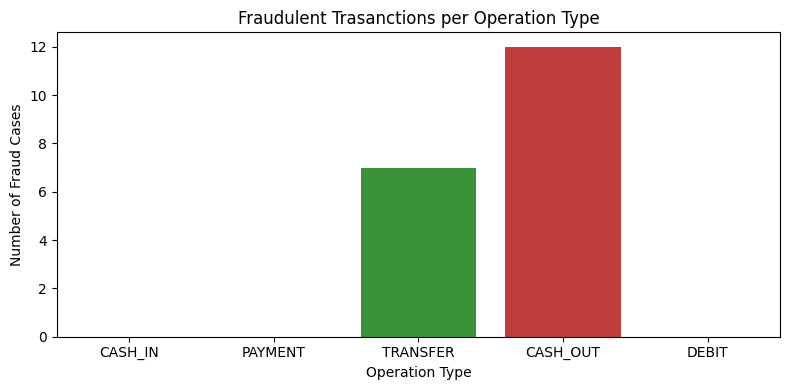

In [8]:
## Viz 1: Fraud per operation type
plt.figure(figsize=(8,4))
sns.barplot(data=dataset, x='type', y='isFraud', hue='type', estimator=sum, errorbar=None)
plt.title('Fraudulent Trasanctions per Operation Type')
plt.xlabel('Operation Type')
plt.ylabel('Number of Fraud Cases')
plt.tight_layout()
plt.show()

In [9]:
## Amount comparison: normal vs average 
print('3. AMOUNT COMPARISON')
amount_stats = dataset.groupby('isFraud')['amount'].describe()[['mean', 'std', 'min','50%', 'max']]
amount_stats.index = ['legitimate (0)', 'Fraud (1)']
print(amount_stats)

3. AMOUNT COMPARISON
                         mean           std      min        50%          max
legitimate (0)  172175.383086  4.628559e+05     1.26   73915.94  17271014.73
Fraud (1)       980262.747895  1.125965e+06  7360.15  636942.02   4953893.08


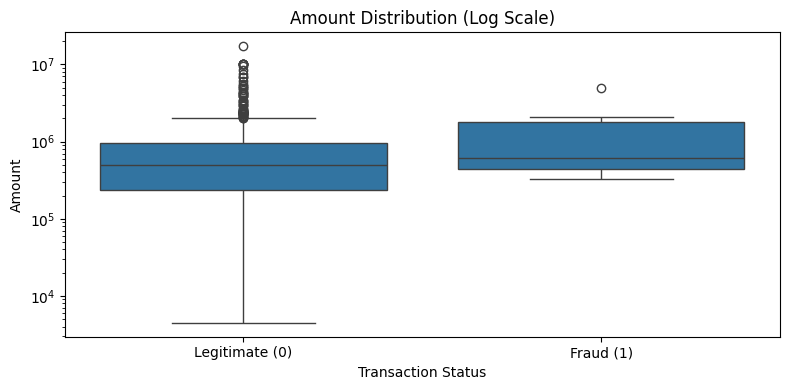

In [10]:
## Viz 2: Amount Distribution
plt.figure(figsize=(8,4))
sns.boxplot(data=dataset[dataset['type'].isin(['TRANSFER', 'CASHOUT'])], x='isFraud', y='amount')
plt.yscale('log')
plt.title('Amount Distribution (Log Scale)')
plt.xticks([0,1], ['Legitimate (0)', 'Fraud (1)'])
plt.xlabel('Transaction Status')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

In [11]:
## 4. Behavioural findings: Exactly $0 after transaction
dataset['zeroOriginBalance'] = (dataset['oldbalanceOrg'] > 0) & (dataset['newbalanceOrig'] == 0)

result = dataset.groupby('isFraud')['zeroOriginBalance'].mean() * 100

print('4. Percentage of Transactions that result in an ending balance of $0')

if False in result.index:
    print(f'Legitimate Transactions: {result.loc[False]:.2f}%')
if True in result.index:
    print(f'Fraudulent Transactions: {result.loc[True]:.2f}%')

4. Percentage of Transactions that result in an ending balance of $0
Legitimate Transactions: 23.30%
Fraudulent Transactions: 94.74%


### Key Findings
1. Risk Concentration: Out of 10,000 analyzed transactions, 19 were fraudulent: 12 were "cash-out" transactions (ATM withdrawals) and 7 were transfers (bank transfers).
2. Account Draining Pattern: Among transactions that left the source account with a balance of exactly \$0.00, 94% were fraudulent transfers, while only 23.30% were legitimate. This indicates that, in the vast majority of cases, attackers transfer the entire available balance.
3. High Amount: Fraudulent operations typically involve significantly higher transfer amounts—averaging.

In [12]:
# Random Forest Predictive Model
## 1. Filter per transaction tyoe (transfer and cash out)
df_model = dataset[dataset['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

## 2. One-Hot Encoding
df_model = pd.get_dummies(df_model, columns=['type'], drop_first=True)

## 3. Define characteristics (x) and objective variable (y)
features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'zeroOriginBalance']

X = df_model[features]
y = df_model['isFraud'].astype(int)

## 4. 80/20 division 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42, stratify=y
)

## Model Training
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 6. Predictions
y_proba = model.predict_proba(X_test)[:, 1]

threshold = 0.10
y_pred = (y_proba >= threshold).astype(int)

# 7. Performance Evaluation
print(f'Classification Report (Threshold = {threshold})')
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print('Financial Confusion Matrix')
print(f'Legitimate Correct Transacions (TN): {tn:,}')
print(f'False Positives - False Alarms (FP) {fp:,}')
print(f'False Negatives - No Detected Frauds (FN) {fn:,}')
print(f'Successfully Blocked Frauds (TP): {tp:,}\n')
print(f'\nROC-AUC Score: {roc_auc_score(y_test, y_proba):.2f}')


Classification Report (Threshold = 0.1)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       863
           1       0.75      0.75      0.75         4

    accuracy                           1.00       867
   macro avg       0.87      0.87      0.87       867
weighted avg       1.00      1.00      1.00       867

Financial Confusion Matrix
Legitimate Correct Transacions (TN): 862
False Positives - False Alarms (FP) 1
False Negatives - No Detected Frauds (FN) 1
Successfully Blocked Frauds (TP): 3


ROC-AUC Score: 0.87


In [13]:
# Save final results
results_df = X_test.copy()
results_df['Real_Fraud'] = y_test
results_df['Predicted_Fraud'] = y_pred
results_df['Fraud_Probability'] = y_proba

results_df.to_csv('fraud_detection_results.csv', index=False)